In [1]:
import pickle

with open("dataset/resplan_numeric_100.pkl", "rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edge_index = data["edge_index"]
edge_attr = data["edge_attr"]
text = data["text"]

print(len(nodes))
print(nodes[0].shape)
print(edge_attr[0].shape)

100
(8, 11)
(10, 10)


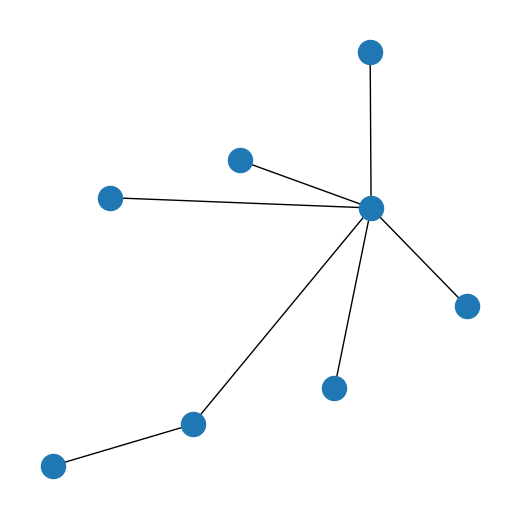

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
i=5
x=nodes[i]
edge_index_1=edge_index[i]
G=nx.Graph()


# node positions from centroid features
cx = x[:,7]
cy = x[:,8]

for n in range(len(x)):
    G.add_node(n, pos=(cx[n], cy[n]))

for s,d in edge_index_1.T:
    G.add_edge(int(s), int(d))

pos = nx.get_node_attributes(G,"pos")

plt.figure(figsize=(5,5))
nx.draw(G,pos,node_size=300)
plt.gca()
plt.show()

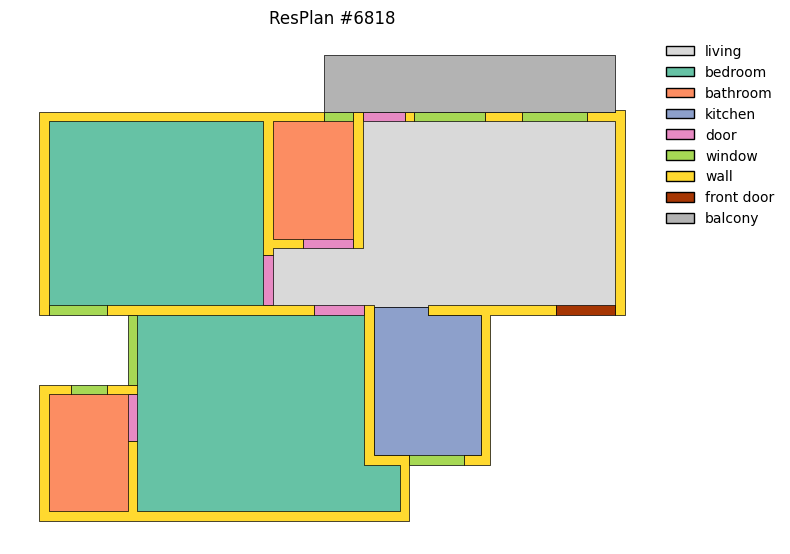

In [3]:
from dataset.resplan_utils import plot_plan

# load numeric subset
with open("dataset/resplan_numeric_100.pkl","rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edges = data["edge_index"]
plan_idx = data["plan_idx"]


orig_idx = plan_idx[i]

# load ResPlan
with open("dataset/ResPlan.pkl","rb") as f:
    plans = pickle.load(f)

plan = plans[orig_idx]

# show floorplan
plot_plan(plan, title=f"ResPlan #{orig_idx}")
plt.show()

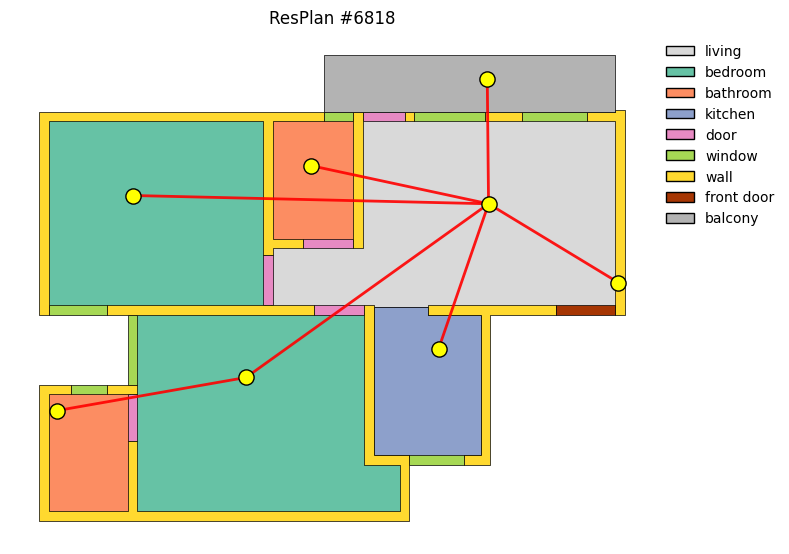

In [4]:
# Draw floorplan first
plot_plan(plan, title=f"ResPlan #{orig_idx}")
ax = plt.gca()

# Floorplan bounds
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
xmin, xmax = min(x0, x1), max(x0, x1)
ymin, ymax = min(y0, y1), max(y0, y1)

# Map normalized node coords (0..1) into floorplan axis coords
pos_plan = {
    k: (
        xmin + float(v[0]) * (xmax - xmin),
        ymin + float(v[1]) * (ymax - ymin),
    )
    for k, v in pos.items()
}

# Overlay graph
edge_coll = nx.draw_networkx_edges(
    G, pos_plan, ax=ax, edge_color="red", width=2.0, alpha=0.9
)
node_coll = nx.draw_networkx_nodes(
    G, pos_plan, ax=ax, node_color="yellow", edgecolors="black", node_size=120, alpha=1.0
)

# Keep graph above floorplan
if edge_coll is not None:
    edge_coll.set_zorder(10)
if node_coll is not None:
    node_coll.set_zorder(11)

# Preserve view/aspect/orientation
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

Building dataset

In [5]:
import torch
from torch_geometric.data import Data

def build_dataset(nodes, edge_index, edge_attr):
    dataset = []

    for i in range(len(nodes)):
        x = torch.tensor(nodes[i], dtype=torch.float32)
        ei = torch.tensor(edge_index[i], dtype=torch.long)
        ea = torch.tensor(edge_attr[i], dtype=torch.float32)

        # target = cx,cy,w,h
        y = x[:, 7:11]   # adjust if ordering differs

        data = Data(
            x=x,
            edge_index=ei,
            edge_attr=ea,
            y=y
        )
        dataset.append(data)

    return dataset

/home/dexter/projects/FloorPlan-Pipeline/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train Test split

In [6]:
dataset = build_dataset(nodes, edge_index, edge_attr)

train_dataset = dataset[:80]
test_dataset  = dataset[80:]

In [7]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1)

In [8]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv


class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4)   # cx,cy,w,h
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = self.conv1(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = torch.relu(x)

        out = self.head(x)
        return out

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RoughLayoutGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
print(device)

cuda


In [11]:
def layout_loss(pred, target):
    # pred,target: [total_nodes,4]
    return torch.nn.functional.l1_loss(pred, target)

Training loop

In [12]:
def train_epoch():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)

        loss = layout_loss(pred, data.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [13]:
@torch.no_grad()
def eval_epoch():
    model.eval()
    total_loss = 0

    for data in test_loader:
        data = data.to(device)
        pred = model(data)
        loss = layout_loss(pred, data.y)
        total_loss += loss.item()

    return total_loss / len(test_loader)

In [14]:
for epoch in range(50):
    train_loss = train_epoch()
    test_loss  = eval_epoch()

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | test {test_loss:.4f}")

Epoch 000 | train 0.2564 | test 0.2236
Epoch 001 | train 0.1992 | test 0.1925
Epoch 002 | train 0.1717 | test 0.1683
Epoch 003 | train 0.1562 | test 0.1585
Epoch 004 | train 0.1408 | test 0.1430
Epoch 005 | train 0.1330 | test 0.1365
Epoch 006 | train 0.1257 | test 0.1309
Epoch 007 | train 0.1168 | test 0.1258
Epoch 008 | train 0.1154 | test 0.1166
Epoch 009 | train 0.1042 | test 0.1120
Epoch 010 | train 0.0974 | test 0.0993
Epoch 011 | train 0.0979 | test 0.1065
Epoch 012 | train 0.0891 | test 0.0925
Epoch 013 | train 0.0793 | test 0.0915
Epoch 014 | train 0.0751 | test 0.0842
Epoch 015 | train 0.0701 | test 0.0856
Epoch 016 | train 0.0670 | test 0.0810
Epoch 017 | train 0.0647 | test 0.0775
Epoch 018 | train 0.0649 | test 0.0763
Epoch 019 | train 0.0618 | test 0.0758
Epoch 020 | train 0.0606 | test 0.0760
Epoch 021 | train 0.0602 | test 0.0730
Epoch 022 | train 0.0613 | test 0.0701
Epoch 023 | train 0.0566 | test 0.0683
Epoch 024 | train 0.0519 | test 0.0681
Epoch 025 | train 0.0512 

In [15]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_prediction(sample_idx=0):
    data = test_dataset[sample_idx].to(device)
    pred = model(data).cpu().numpy()
    gt   = data.y.cpu().numpy()

    fig, ax = plt.subplots(figsize=(5,5))

    for box, color in [(gt,"green"), (pred,"red")]:
        for cx,cy,w,h in box:
            x0 = cx - w/2
            y0 = cy - h/2
            rect = plt.Rectangle(
                (x0,y0), w, h,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_aspect("equal")
    plt.show()

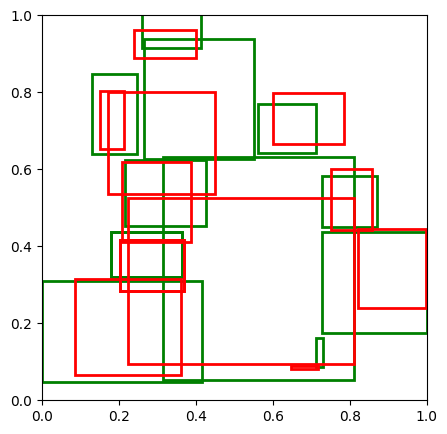

In [16]:
visualize_prediction(1)

In [17]:
import torch
import matplotlib.pyplot as plt
import networkx as nx


@torch.no_grad()
def visualize_sample(i, model, dataset, plans, plan_idx):
    """
    i         : index in dataset (train or test)
    dataset   : PyG dataset
    plans     : full ResPlan list
    plan_idx  : mapping dataset idx → ResPlan idx
    """

    model.eval()

    data = dataset[i].to(next(model.parameters()).device)
    pred = model(data).cpu().numpy()
    gt   = data.y.cpu().numpy()

    # --- correct floorplan ---
    orig = plan_idx[i]
    plan = plans[orig]

    plot_plan(plan, title=f"Dataset {i} → ResPlan {orig}")
    ax = plt.gca()

    # floorplan axis bounds
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xmin, xmax = min(x0, x1), max(x0, x1)
    ymin, ymax = min(y0, y1), max(y0, y1)

    # --- graph nodes ---
    x = data.x.cpu().numpy()
    cx = x[:, 7]
    cy = x[:, 8]

    G = nx.Graph()
    for n in range(len(x)):
        G.add_node(n, pos=(cx[n], cy[n]))

    ei = data.edge_index.cpu().numpy()
    for s, d in ei.T:
        G.add_edge(int(s), int(d))

    pos = nx.get_node_attributes(G, "pos")

    # normalized → floorplan coords
    pos_plan = {
        k: (
            xmin + float(v[0]) * (xmax - xmin),
            ymin + float(v[1]) * (ymax - ymin),
        )
        for k, v in pos.items()
    }

    nx.draw_networkx_edges(G, pos_plan, ax=ax, edge_color="red", width=2)
    nx.draw_networkx_nodes(
        G, pos_plan, ax=ax,
        node_color="yellow",
        edgecolors="black",
        node_size=120
    )

    # --- boxes ---
    def draw_boxes(boxes, color):
        for cx, cy, w, h in boxes:
            x0 = xmin + (cx - w/2) * (xmax - xmin)
            y0 = ymin + (cy - h/2) * (ymax - ymin)
            ww = w * (xmax - xmin)
            hh = h * (ymax - ymin)

            rect = plt.Rectangle(
                (x0, y0), ww, hh,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)

    draw_boxes(gt,  "green")   # GT
    draw_boxes(pred,"blue")    # predicted

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

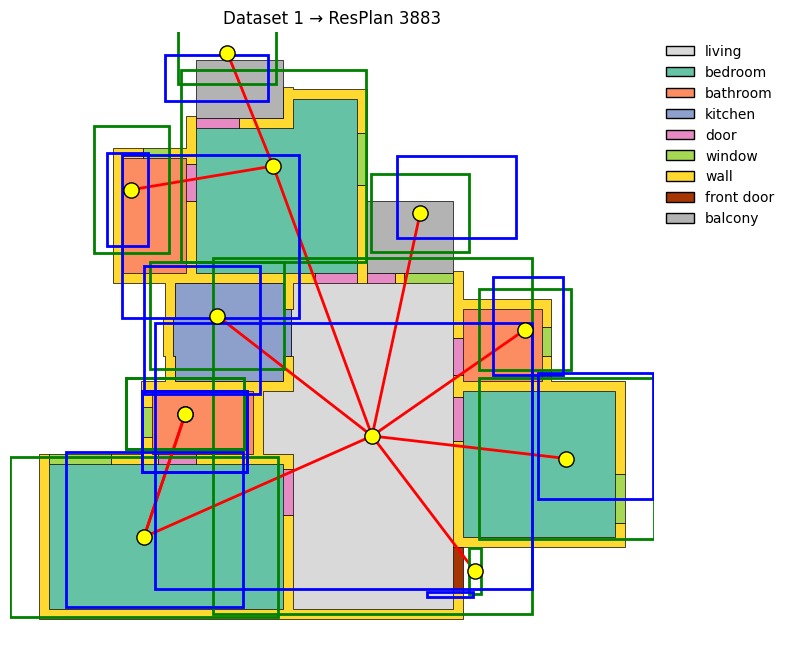

In [18]:
test_plan_idx = plan_idx[80:]
visualize_sample(
    i=1,
    model=model,
    dataset=test_dataset,
    plans=plans,
    plan_idx=test_plan_idx
)

In [21]:
@torch.no_grad()
def visualize_pred_boxes(i, model, dataset):
    model.eval()

    device = next(model.parameters()).device
    data = dataset[i].to(device)

    pred = model(data).cpu().numpy()  # (cx,cy,w,h)

    fig, ax = plt.subplots(figsize=(5,5))

    for cx, cy, w, h in pred:
        x0 = cx - w/2
        y0 = cy - h/2

        rect = plt.Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
            edgecolor="blue",
            linewidth=2
        )
        ax.add_patch(rect)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    plt.title(f"Predicted layout — sample {i}")
    plt.show()

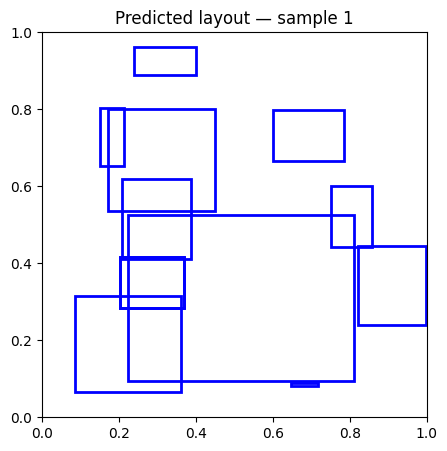

In [22]:
visualize_pred_boxes(
    i=1,
    model=model,
    dataset=test_dataset,

)

In [23]:
import torch


def overlap_loss(boxes):
    """
    boxes: [N,4] (cx,cy,w,h) normalized
    penalize any overlap between any pair
    """
    cx, cy, w, h = boxes.T

    x1 = cx - w/2
    y1 = cy - h/2
    x2 = cx + w/2
    y2 = cy + h/2

    loss = 0.0
    N = boxes.shape[0]

    for i in range(N):
        for j in range(i+1, N):
            ix1 = torch.max(x1[i], x1[j])
            iy1 = torch.max(y1[i], y1[j])
            ix2 = torch.min(x2[i], x2[j])
            iy2 = torch.min(y2[i], y2[j])

            iw = torch.clamp(ix2 - ix1, min=0)
            ih = torch.clamp(iy2 - iy1, min=0)

            inter = iw * ih
            loss += inter

    return loss / (N*N + 1e-6)

In [24]:
def adjacency_loss(boxes, edge_index):
    """
    boxes: [N,4]
    edge_index: [2,M]
    encourage connected rooms to be close
    """
    cx, cy, w, h = boxes.T

    loss = 0.0
    M = edge_index.shape[1]

    for k in range(M):
        i = edge_index[0, k]
        j = edge_index[1, k]

        dx = torch.abs(cx[i] - cx[j])
        dy = torch.abs(cy[i] - cy[j])

        tx = (w[i] + w[j]) / 2
        ty = (h[i] + h[j]) / 2

        dist = torch.relu(dx - tx) + torch.relu(dy - ty)
        loss += dist

    return loss / (M + 1e-6)

In [25]:
def layout_loss(pred, target, edge_index,
                lam_overlap=5.0,
                lam_adj=2.0):
    
    L_layout = torch.nn.functional.l1_loss(pred, target)
    L_overlap = overlap_loss(pred)
    L_adj = adjacency_loss(pred, edge_index)

    return L_layout + lam_overlap*L_overlap + lam_adj*L_adj

In [27]:
def train_epoch():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)

        loss = layout_loss(pred, data.y, data.edge_index)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [29]:
@torch.no_grad()
def eval_epoch():
    model.eval()
    total_loss = 0

    for data in test_loader:
        data = data.to(device)
        pred = model(data)
        loss = layout_loss(pred, data.y,data.edge_index)
        total_loss += loss.item()

    return total_loss / len(test_loader)

In [30]:
def train_epoch():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)

        loss = layout_loss(pred, data.y, data.edge_index)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [32]:
for epoch in range(50):
    train_loss = train_epoch()
    test_loss  = eval_epoch()

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | test {test_loss:.4f}")

Epoch 000 | train 0.0916 | test 0.1049
Epoch 001 | train 0.0880 | test 0.0940
Epoch 002 | train 0.0786 | test 0.0926
Epoch 003 | train 0.0781 | test 0.0912
Epoch 004 | train 0.0760 | test 0.0957
Epoch 005 | train 0.0724 | test 0.0915
Epoch 006 | train 0.0665 | test 0.0834
Epoch 007 | train 0.0638 | test 0.0825
Epoch 008 | train 0.0627 | test 0.0830
Epoch 009 | train 0.0628 | test 0.0830
Epoch 010 | train 0.0634 | test 0.0813
Epoch 011 | train 0.0625 | test 0.0834
Epoch 012 | train 0.0598 | test 0.0849
Epoch 013 | train 0.0589 | test 0.0798
Epoch 014 | train 0.0610 | test 0.0825
Epoch 015 | train 0.0585 | test 0.0791
Epoch 016 | train 0.0574 | test 0.0822
Epoch 017 | train 0.0583 | test 0.0810
Epoch 018 | train 0.0564 | test 0.0811
Epoch 019 | train 0.0590 | test 0.0817
Epoch 020 | train 0.0576 | test 0.0790
Epoch 021 | train 0.0575 | test 0.0819
Epoch 022 | train 0.0605 | test 0.0778
Epoch 023 | train 0.0613 | test 0.0834
Epoch 024 | train 0.0616 | test 0.0886
Epoch 025 | train 0.0603 

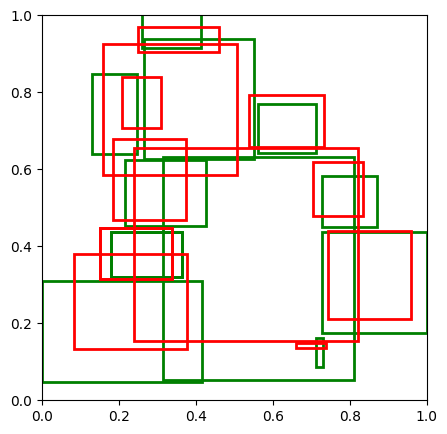

In [33]:
visualize_prediction(1)

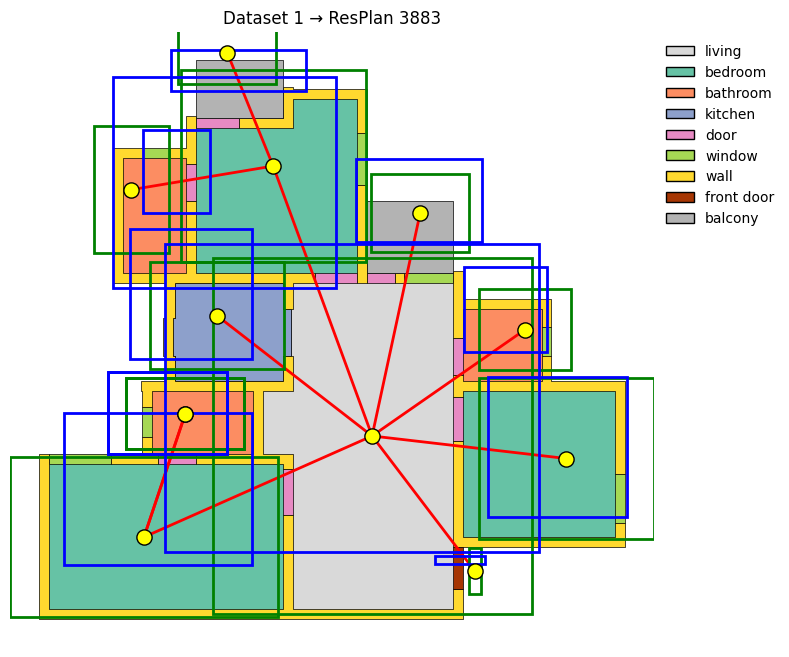

In [34]:
test_plan_idx = plan_idx[80:]
visualize_sample(
    i=1,
    model=model,
    dataset=test_dataset,
    plans=plans,
    plan_idx=test_plan_idx
)

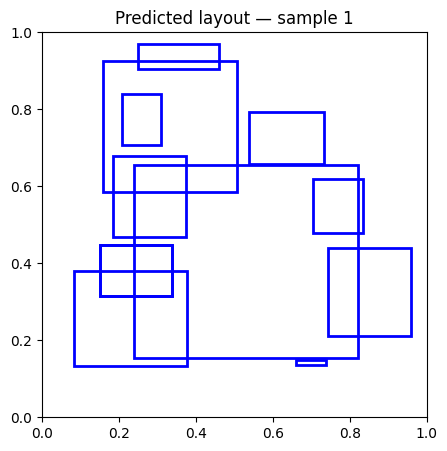

In [35]:
visualize_pred_boxes(
    i=1,
    model=model,
    dataset=test_dataset,

)